In [1]:
%pip install pyod

In [2]:
import numpy as np
import matplotlib.pyplot as plt

mean = [5, 10, 2]
cov_matrix_original = [[3, 2, 2], [2, 10, 1], [2, 1, 2]]

data = np.random.multivariate_normal(mean, cov_matrix_original, 500)

data_centered = data - np.mean(data, axis=0)

cov_matrix = np.cov(data_centered, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [3]:
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

principal_components = np.dot(data_centered, sorted_eigenvectors)

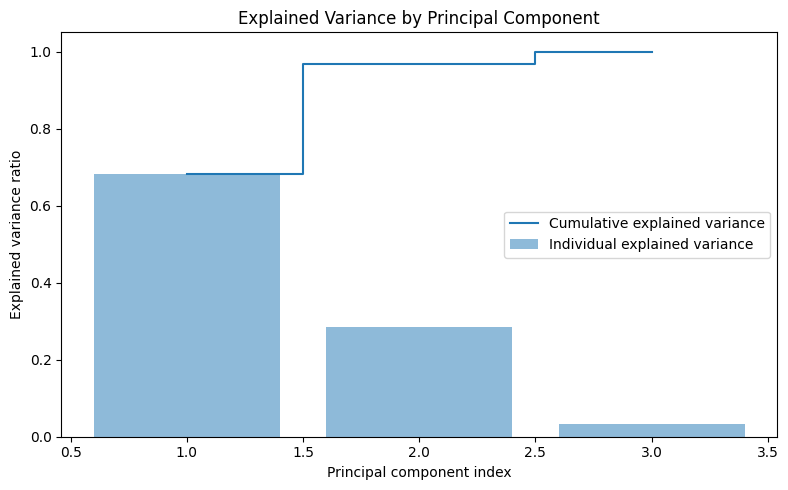

In [4]:
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)

cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Explained Variance by Principal Component')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [5]:
pc_stds = np.std(principal_components, axis=0)

absolute_deviations = np.abs(principal_components)

outlier_threshold = 3 * pc_stds
outlier_mask = np.any(absolute_deviations > outlier_threshold, axis=1)
outlier_indices = np.where(outlier_mask)[0]

In [6]:
centroid = np.mean(data, axis=0)

distances = np.linalg.norm(data - centroid, axis=1)

mean_distance = np.mean(distances)
std_distance = np.std(distances)
normalized_distances = (distances - mean_distance) / std_distance

outlier_mask_centroid = np.abs(normalized_distances) > 3
outlier_indices_centroid = np.where(outlier_mask_centroid)[0]

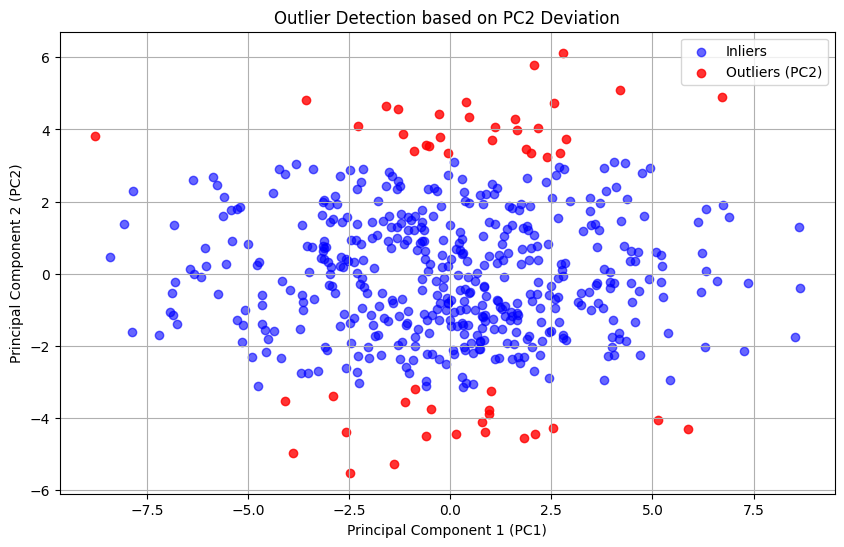

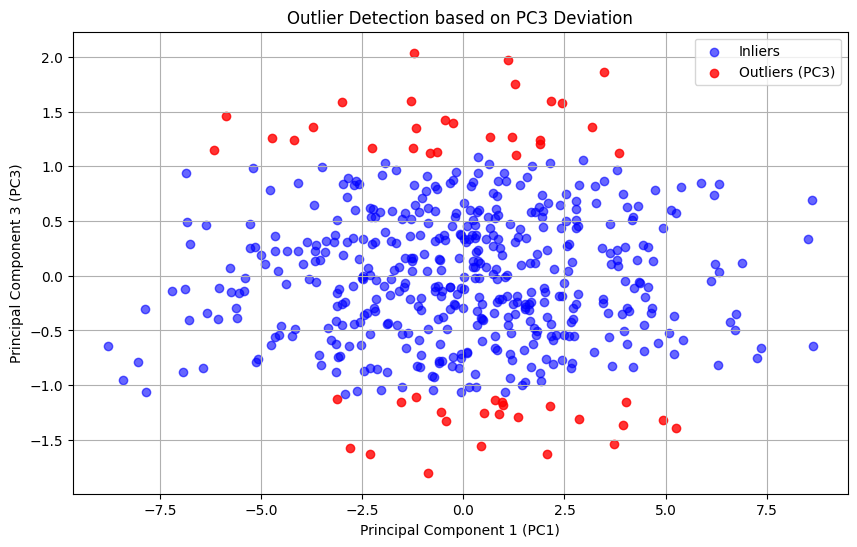

In [7]:
contamination_rate = 0.1

abs_deviation_pc2 = np.abs(principal_components[:, 1])

threshold_pc2 = np.quantile(abs_deviation_pc2, 1 - contamination_rate)

outlier_mask_pc2 = abs_deviation_pc2 > threshold_pc2
outlier_indices_pc2 = np.where(outlier_mask_pc2)[0]

plt.figure(figsize=(10, 6))
plt.scatter(principal_components[~outlier_mask_pc2, 0], principal_components[~outlier_mask_pc2, 1], label='Inliers', alpha=0.6, color='blue')
plt.scatter(principal_components[outlier_mask_pc2, 0], principal_components[outlier_mask_pc2, 1], label='Outliers (PC2)', alpha=0.8, color='red')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('Outlier Detection based on PC2 Deviation')
plt.legend()
plt.grid(True)
plt.show()

abs_deviation_pc3 = np.abs(principal_components[:, 2])

threshold_pc3 = np.quantile(abs_deviation_pc3, 1 - contamination_rate)

outlier_mask_pc3 = abs_deviation_pc3 > threshold_pc3
outlier_indices_pc3 = np.where(outlier_mask_pc3)[0]

plt.figure(figsize=(10, 6))
plt.scatter(principal_components[~outlier_mask_pc3, 0], principal_components[~outlier_mask_pc3, 2], label='Inliers', alpha=0.6, color='blue')
plt.scatter(principal_components[outlier_mask_pc3, 0], principal_components[outlier_mask_pc3, 2], label='Outliers (PC3)', alpha=0.8, color='red')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 3 (PC3)')
plt.title('Outlier Detection based on PC3 Deviation')
plt.legend()
plt.grid(True)
plt.show()

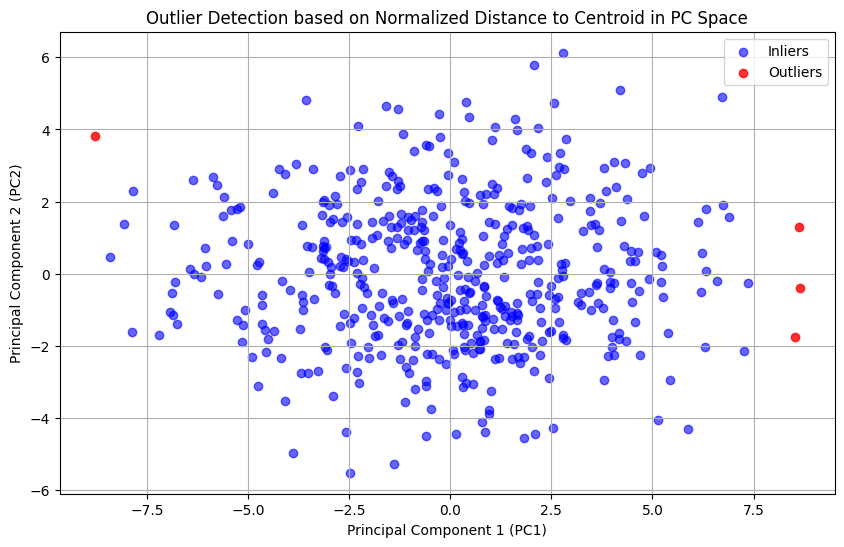

In [8]:
centroid_pc = np.mean(principal_components, axis=0)

distances_pc_space = np.linalg.norm(principal_components - centroid_pc, axis=1)

mean_distance_pc_space = np.mean(distances_pc_space)
std_distance_pc_space = np.std(distances_pc_space)
normalized_distances_pc_space = (distances_pc_space - mean_distance_pc_space) / std_distance_pc_space

outlier_mask_pc_centroid = np.abs(normalized_distances_pc_space) > 3
outlier_indices_pc_centroid = np.where(outlier_mask_pc_centroid)[0]

plt.figure(figsize=(10, 6))
plt.scatter(principal_components[~outlier_mask_pc_centroid, 0], principal_components[~outlier_mask_pc_centroid, 1], label='Inliers', alpha=0.6, color='blue')
plt.scatter(principal_components[outlier_mask_pc_centroid, 0], principal_components[outlier_mask_pc_centroid, 1], label='Outliers', alpha=0.8, color='red')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('Outlier Detection based on Normalized Distance to Centroid in PC Space')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = loadmat('/content/shuttle 1.mat')

X = data['X']
y = data['y'].ravel()

X_train, X_test, y_train, y_test = train_test_split(X[:20000], y[:20000], test_size=0.6) # I need to subsample in order to not oom

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]
contamination_rate = np.sum(y_train == 1) / len(y_train)

Original X shape: (49097, 9)
Original y shape: (49097,)


In [13]:
from sklearn.metrics import balanced_accuracy_score
from pyod.models.pca import PCA
from pyod.models.kpca import KPCA

pca_model = PCA(n_components=n_features, contamination=contamination_rate)
pca_model.fit(X_train_scaled)

pca_train_labels = pca_model.labels_

pca_test_predictions = pca_model.predict(X_test_scaled)

pca_train_balanced_accuracy = balanced_accuracy_score(y_train, pca_train_labels)

pca_test_balanced_accuracy = balanced_accuracy_score(y_test, pca_test_predictions)

kpca_model = KPCA(n_components=n_features, contamination=contamination_rate)

kpca_model.fit(X_train_scaled)

kpca_train_labels = kpca_model.labels_

kpca_test_predictions = kpca_model.predict(X_test_scaled)

kpca_train_balanced_accuracy = balanced_accuracy_score(y_train, kpca_train_labels)

kpca_test_balanced_accuracy = balanced_accuracy_score(y_test, kpca_test_predictions)

print(f"\nBalanced Accuracy Scores:")
print(f"  PCA (Training): {pca_train_balanced_accuracy:.4f}")
print(f"  PCA (Test):     {pca_test_balanced_accuracy:.4f}")
print(f"  KPCA (Training): {kpca_train_balanced_accuracy:.4f}")
print(f"  KPCA (Test):     {kpca_test_balanced_accuracy:.4f}")


Balanced Accuracy Scores:
  PCA (Training): 0.9712
  PCA (Test):     0.9740
  KPCA (Training): 0.5682
  KPCA (Test):     0.5961


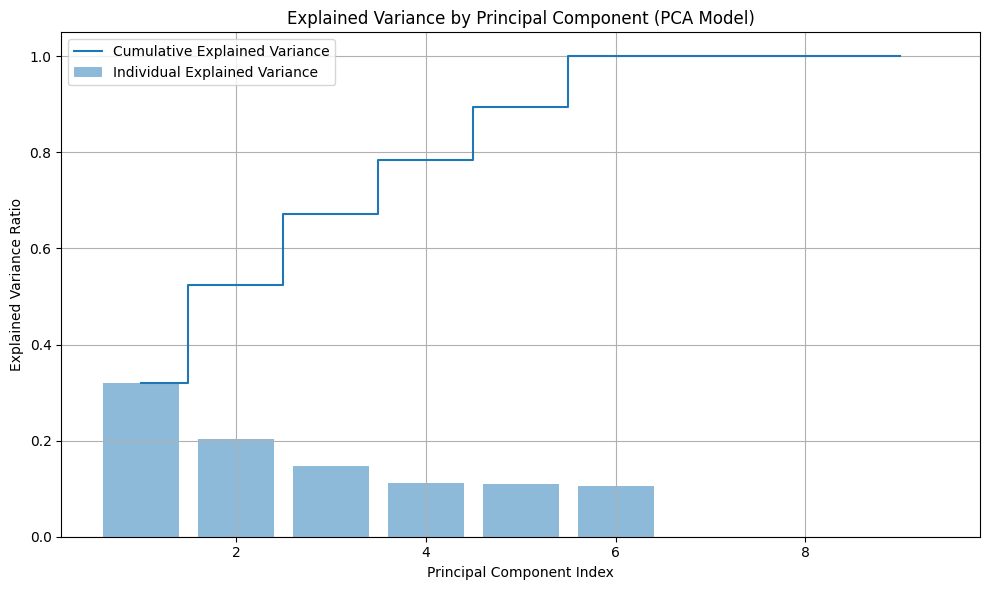

In [14]:
explained_variance_ratio_pca = pca_model.explained_variance_ratio_
cumulative_explained_variance_pca = np.cumsum(explained_variance_ratio_pca)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio_pca) + 1), explained_variance_ratio_pca, alpha=0.5, align='center', label='Individual Explained Variance')
plt.step(range(1, len(cumulative_explained_variance_pca) + 1), cumulative_explained_variance_pca, where='mid', label='Cumulative Explained Variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('Explained Variance by Principal Component (PCA Model)')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.preprocessing import MinMaxScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

min_max_scaler = MinMaxScaler()
X_train_scaled = min_max_scaler.fit_transform(X_train)
X_test_scaled = min_max_scaler.transform(X_test)

contamination_rate = np.sum(y_train == 1) / len(y_train)

In [17]:
import tensorflow as tf

class Autoencoder(tf.keras.Model):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.Dense(8, activation='relu', input_shape=(input_dim,)),
            tf.keras.layers.Dense(5, activation='relu'),
            tf.keras.layers.Dense(3, activation='relu')
        ])
        self.decoder = tf.keras.Sequential([
            tf.keras.layers.Dense(5, activation='relu'),
            tf.keras.layers.Dense(8, activation='relu'),
            tf.keras.layers.Dense(input_dim, activation='sigmoid')
        ])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

Autoencoder model class defined.


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0486 - val_loss: 0.0461
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0452 - val_loss: 0.0433
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0427 - val_loss: 0.0421
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0417 - val_loss: 0.0413
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0409 - val_loss: 0.0406
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0403 - val_loss: 0.0399
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0396 - val_loss: 0.0393
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0390 - val_loss: 0.0386
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0384 - val_loss: 0.0379
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0376 - val_loss: 0.0373
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0371 - val_loss: 0.0367
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0365 - 

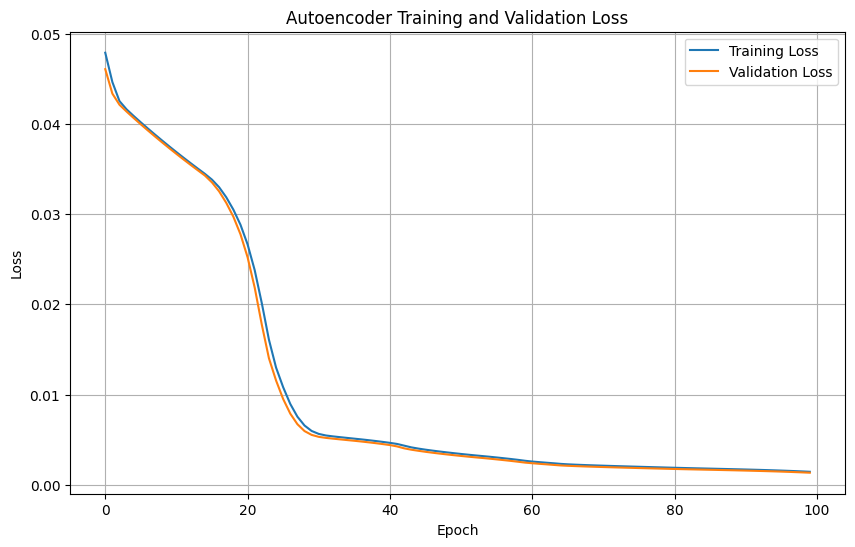

In [18]:
input_dim = X_train_scaled.shape[1]
autoencoder = Autoencoder(input_dim=input_dim)

autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(X_train_scaled, X_train_scaled,
                          epochs=100,
                          batch_size=1024,
                          shuffle=True,
                          validation_data=(X_test_scaled, X_test_scaled))

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Autoencoder Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
X_train_reconstructed = autoencoder.predict(X_train_scaled)
X_test_reconstructed = autoencoder.predict(X_test_scaled)

mse = tf.keras.losses.MeanSquaredError(reduction=tf.keras.losses.Reduction.NONE)
train_reconstruction_error = mse(X_train_scaled, X_train_reconstructed).numpy()
test_reconstruction_error = mse(X_test_scaled, X_test_reconstructed).numpy()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [23]:
threshold = np.quantile(train_reconstruction_error, 1 - contamination_rate)

is_outlier_train_ae = train_reconstruction_error > threshold
is_outlier_test_ae = test_reconstruction_error > threshold

ae_train_labels = is_outlier_train_ae.astype(int)
ae_test_predictions = is_outlier_test_ae.astype(int)

ae_train_balanced_accuracy = balanced_accuracy_score(y_train, ae_train_labels)
ae_test_balanced_accuracy = balanced_accuracy_score(y_test, ae_test_predictions)

print(f"\nAutoencoder Balanced Accuracy Scores:")
print(f"  Training: {ae_train_balanced_accuracy:.4f}")
print(f"  Test:     {ae_test_balanced_accuracy:.4f}")


Autoencoder Balanced Accuracy Scores:
  Training: 0.9654
  Test:     0.9645


In [25]:
import tensorflow as tf
import numpy as np

# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Normalize the pixel values
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# 3. Reshape x_train and x_test to include a channel dimension
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

# 4. Create x_test_noisy by adding random normal noise to x_test
noise_factor = 0.35
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

# 5. Clip the values in x_test_noisy to ensure they remain within the [0, 1] range
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"x_test_noisy shape: {x_test_noisy.shape}")
print("MNIST dataset loaded, normalized, reshaped, and noisy test data created.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)
x_test_noisy shape: (10000, 28, 28, 1)
MNIST dataset loaded, normalized, reshaped, and noisy test data created.


In [ ]:
class ConvAutoencoder(tf.keras.Model):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(28, 28, 1)),
            tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=2),
            tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', strides=2),
            tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same', strides=1)
        ])

        self.decoder = tf.keras.Sequential([
            tf.keras.layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same', strides=1),
            tf.keras.layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same', strides=2),
            tf.keras.layers.Conv2DTranspose(1, (3, 3), activation='sigmoid', padding='same', strides=2)
        ])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

conv_autoencoder = ConvAutoencoder()
conv_autoencoder.compile(optimizer='adam', loss='mse')

history = conv_autoencoder.fit(x_train, x_train,
                                epochs=10,
                                batch_size=64,
                                shuffle=True,
                                validation_data=(x_test, x_test))

print("Convolutional Autoencoder designed and trained.")

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 99s 101ms/step - loss: 0.1197 - val_loss: 0.1140
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 137s 96ms/step - loss: 0.1118 - val_loss: 0.1140
Epoch 3/10
